# Part 1c: Monte Carlo Dropout for Uncertainty Estimation

Monte Carlo (MC) Dropout is a technique that uses dropout at inference time to estimate prediction uncertainty. By running multiple forward passes with dropout enabled, we can approximate Bayesian inference.

## Topics Covered:
1. Understanding Epistemic vs Aleatoric Uncertainty
2. MC Dropout in TensorFlow/Keras
3. MC Dropout in PyTorch
4. MCAlphaDropout for SELU networks
5. Visualizing Prediction Uncertainty

**Author:** Advanced Deep Learning Course Assignment

## Understanding Uncertainty

### Types of Uncertainty:

1. **Epistemic Uncertainty (Model Uncertainty)**
   - Uncertainty due to lack of knowledge/data
   - Can be reduced with more training data
   - MC Dropout estimates this type

2. **Aleatoric Uncertainty (Data Uncertainty)**
   - Inherent noise in the data
   - Cannot be reduced with more data
   - Examples: sensor noise, ambiguous labels

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)

---
# Part A: Monte Carlo Dropout in TensorFlow/Keras

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")
tf.random.set_seed(42)

TensorFlow version: 2.19.0


In [3]:
# Load and prepare MNIST data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and reshape
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)

# Use subset for faster training
X_train = X_train[:10000]
y_train = y_train[:10000]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (10000, 784)
Test set: (10000, 784)


## MC Dropout Implementation in Keras

The key insight is to keep dropout ACTIVE during inference by using `training=True`.

In [4]:
class MCDropout(keras.layers.Dropout):
    """
    Monte Carlo Dropout layer that keeps dropout active during inference.

    Unlike regular Dropout, this layer applies dropout during both
    training AND inference, allowing us to estimate uncertainty.
    """
    def call(self, inputs, training=None):
        # Always apply dropout (ignore training flag)
        return super().call(inputs, training=True)


def create_mc_dropout_model(dropout_rate=0.3):
    """
    Create a model with MC Dropout layers.
    """
    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        MCDropout(dropout_rate),
        layers.Dense(256, activation='relu'),
        MCDropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        MCDropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train the model
print("Training MC Dropout Model (TensorFlow)...")
mc_model_tf = create_mc_dropout_model(dropout_rate=0.3)
mc_model_tf.summary()

Training MC Dropout Model (TensorFlow)...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout (MCDropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_1 (MCDropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mc_dropout_2 (MCDropout)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 300,938 (1.15 MB)

 Trainable params: 300,938 (1.15 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train the model
history = mc_model_tf.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.7651 - loss: 0.7368 - val_accuracy: 0.8840 - val_loss: 0.3598
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9126 - loss: 0.3084 - val_accuracy: 0.9220 - val_loss: 0.2934
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9317 - loss: 0.2369 - val_accuracy: 0.9270 - val_loss: 0.2430
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9449 - loss: 0.1790 - val_accuracy: 0.9330 - val_loss: 0.2494
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9540 - loss: 0.1507 - val_accuracy: 0.9280 - val_loss: 0.2472
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9614 - loss: 0.1212 - val_accuracy: 0.9360 - val_loss: 0.2418
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9624 - loss: 0.1228 - val_accuracy: 0.9410 - val_loss: 0.2311
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9702 - loss: 0.1037 - val_accuracy: 0

In [6]:
def mc_predict_tf(model, X, n_samples=100):
    """
    Make predictions with Monte Carlo sampling.

    Args:
        model: Keras model with MC Dropout layers
        X: Input data
        n_samples: Number of MC samples (forward passes)

    Returns:
        mean_predictions: Mean of all predictions
        std_predictions: Standard deviation (uncertainty)
        all_predictions: All MC samples
    """
    # Collect predictions from multiple forward passes
    predictions = np.array([model(X, training=True).numpy() for _ in range(n_samples)])

    # Calculate statistics
    mean_predictions = predictions.mean(axis=0)
    std_predictions = predictions.std(axis=0)

    return mean_predictions, std_predictions, predictions

# Make MC predictions on test set
print("Making MC predictions with 100 samples...")
mean_preds, std_preds, all_preds = mc_predict_tf(mc_model_tf, X_test[:1000], n_samples=100)

print(f"Mean predictions shape: {mean_preds.shape}")
print(f"Std predictions shape: {std_preds.shape}")

Making MC predictions with 100 samples...
Mean predictions shape: (1000, 10)
Std predictions shape: (1000, 10)


In [7]:
# Calculate predictive uncertainty for each sample
# Using entropy of mean prediction as uncertainty measure
def calculate_entropy(probs):
    """Calculate entropy of probability distribution."""
    return -np.sum(probs * np.log(probs + 1e-10), axis=-1)

# Predictive entropy
predictive_entropy = calculate_entropy(mean_preds)

# Mutual information (epistemic uncertainty)
# MI = H[E[p]] - E[H[p]]
expected_entropy = np.mean([calculate_entropy(p) for p in all_preds], axis=0)
mutual_information = predictive_entropy - expected_entropy

print(f"Average predictive entropy: {predictive_entropy.mean():.4f}")
print(f"Average mutual information: {mutual_information.mean():.4f}")

Average predictive entropy: 0.1320
Average mutual information: 0.0607


Examples with LOW uncertainty (high confidence):


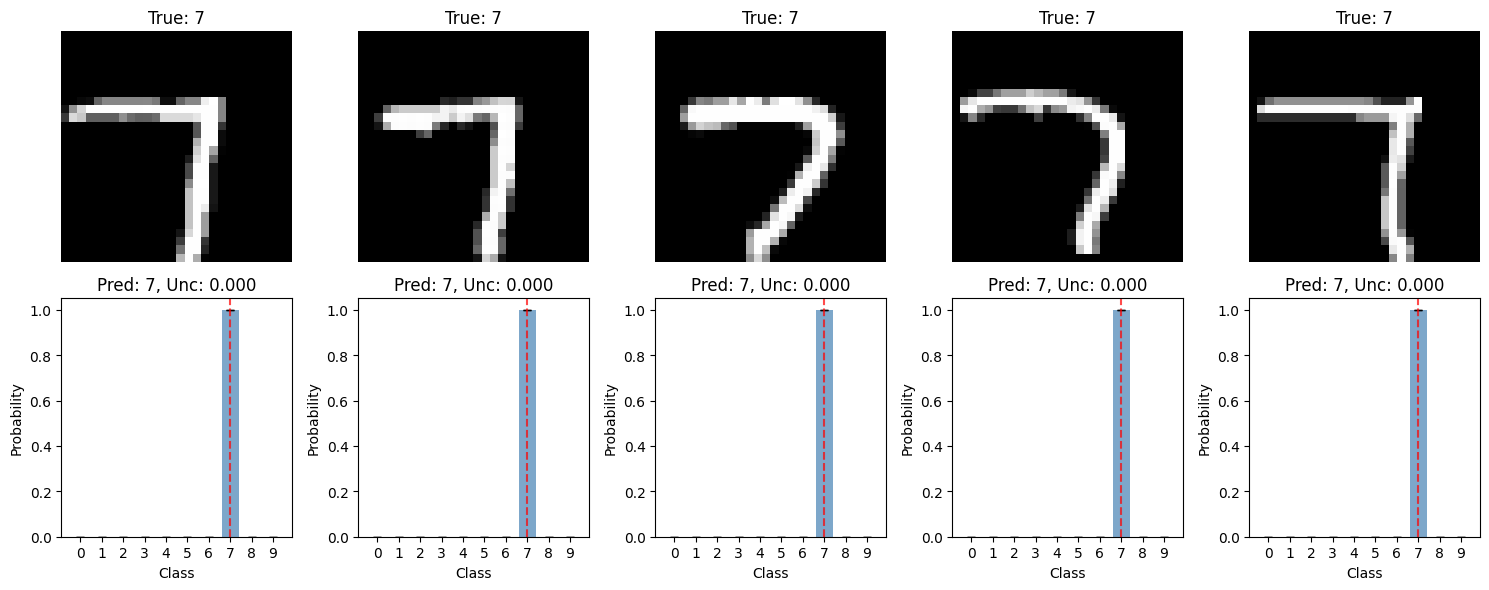

In [8]:
# Visualize uncertainty for specific examples
def visualize_mc_predictions(X, y_true, mean_preds, std_preds, indices, original_shape=(28, 28)):
    """
    Visualize predictions with uncertainty bars.
    """
    fig, axes = plt.subplots(2, len(indices), figsize=(15, 6))

    for i, idx in enumerate(indices):
        # Show image
        axes[0, i].imshow(X[idx].reshape(original_shape), cmap='gray')
        axes[0, i].set_title(f"True: {y_true[idx]}")
        axes[0, i].axis('off')

        # Show prediction distribution with uncertainty
        classes = np.arange(10)
        axes[1, i].bar(classes, mean_preds[idx], yerr=std_preds[idx],
                      capsize=3, alpha=0.7, color='steelblue')
        pred_class = np.argmax(mean_preds[idx])
        axes[1, i].axvline(x=pred_class, color='red', linestyle='--', alpha=0.7)
        axes[1, i].set_xlabel('Class')
        axes[1, i].set_ylabel('Probability')
        axes[1, i].set_title(f"Pred: {pred_class}, Unc: {std_preds[idx].max():.3f}")
        axes[1, i].set_xticks(classes)

    plt.tight_layout()
    plt.show()

# Show examples with LOW uncertainty (confident predictions)
low_uncertainty_idx = np.argsort(std_preds.max(axis=1))[:5]
print("Examples with LOW uncertainty (high confidence):")
visualize_mc_predictions(X_test[:1000], y_test[:1000], mean_preds, std_preds, low_uncertainty_idx)

Examples with HIGH uncertainty (low confidence):


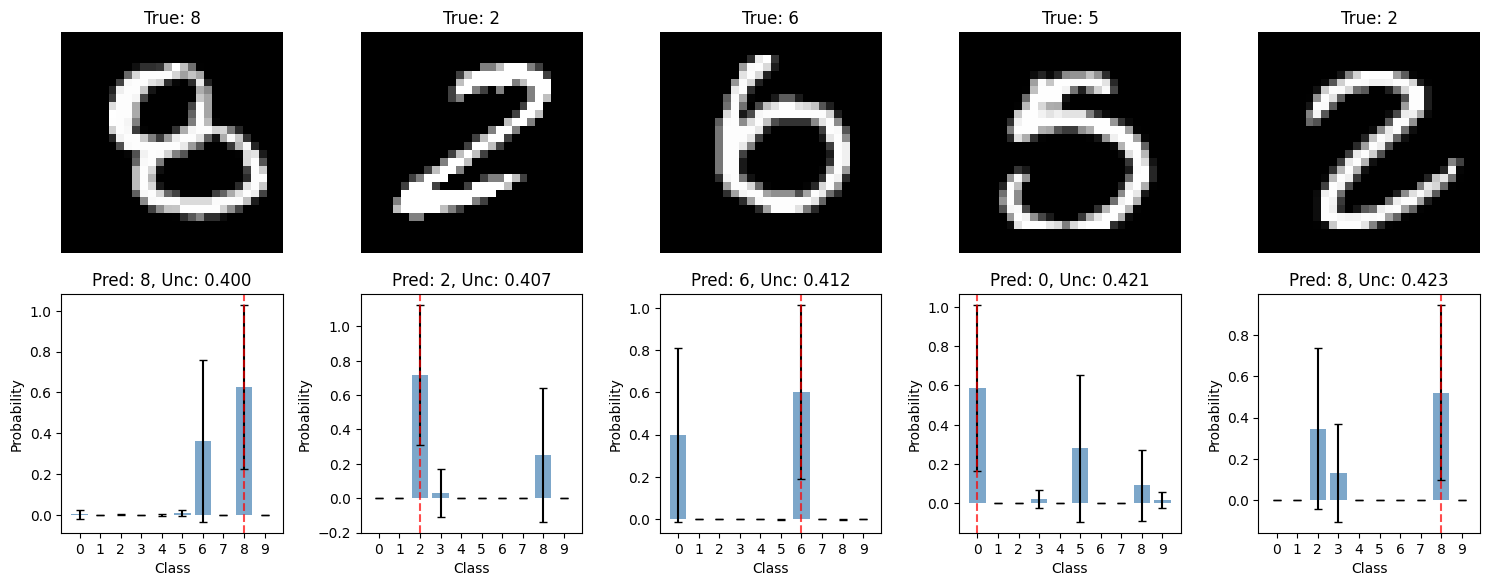

In [9]:
# Show examples with HIGH uncertainty (uncertain predictions)
high_uncertainty_idx = np.argsort(std_preds.max(axis=1))[-5:]
print("Examples with HIGH uncertainty (low confidence):")
visualize_mc_predictions(X_test[:1000], y_test[:1000], mean_preds, std_preds, high_uncertainty_idx)

In [10]:
# Compare accuracy on high vs low uncertainty samples
pred_classes = np.argmax(mean_preds, axis=1)
max_uncertainty = std_preds.max(axis=1)

# Split by uncertainty threshold
threshold = np.median(max_uncertainty)
low_unc_mask = max_uncertainty < threshold
high_unc_mask = max_uncertainty >= threshold

low_unc_acc = np.mean(pred_classes[low_unc_mask] == y_test[:1000][low_unc_mask])
high_unc_acc = np.mean(pred_classes[high_unc_mask] == y_test[:1000][high_unc_mask])

print(f"Accuracy on LOW uncertainty samples: {low_unc_acc:.4f}")
print(f"Accuracy on HIGH uncertainty samples: {high_unc_acc:.4f}")
print(f"\nAs expected, the model is more accurate on samples where it's more confident!")

Accuracy on LOW uncertainty samples: 0.9980
Accuracy on HIGH uncertainty samples: 0.9080

As expected, the model is more accurate on samples where it's more confident!


## MCAlphaDropout for SELU Networks

When using SELU activation (Self-Normalizing Neural Networks), regular dropout breaks the self-normalizing property. MCAlphaDropout maintains the mean and variance.

In [11]:
class MCAlphaDropout(keras.layers.AlphaDropout):
    """
    Monte Carlo Alpha Dropout for SELU networks.

    Alpha Dropout maintains the self-normalizing property of SELU:
    - Randomly sets inputs to negative saturation value (not zero)
    - Preserves mean and variance of inputs
    """
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)


def create_selu_mc_model(dropout_rate=0.1):
    """
    Create a Self-Normalizing Neural Network with MC Alpha Dropout.

    SELU networks use:
    - SELU activation
    - LeCun normal initialization
    - Alpha Dropout (not regular dropout)
    """
    model = keras.Sequential([
        layers.Dense(256, activation='selu',
                    kernel_initializer='lecun_normal',
                    input_shape=(784,)),
        MCAlphaDropout(dropout_rate),

        layers.Dense(256, activation='selu',
                    kernel_initializer='lecun_normal'),
        MCAlphaDropout(dropout_rate),

        layers.Dense(128, activation='selu',
                    kernel_initializer='lecun_normal'),
        MCAlphaDropout(dropout_rate),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create and train SELU model
print("Training SELU + MCAlphaDropout Model...")
selu_model = create_selu_mc_model(dropout_rate=0.1)

selu_history = selu_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Training SELU + MCAlphaDropout Model...
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7919 - loss: 0.6614 - val_accuracy: 0.8770 - val_loss: 0.4017
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8877 - loss: 0.3669 - val_accuracy: 0.8920 - val_loss: 0.3781
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9119 - loss: 0.2797 - val_accuracy: 0.9070 - val_loss: 0.3012
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9313 - loss: 0.2221 - val_accuracy: 0.9220 - val_loss: 0.2634
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9426 - loss: 0.1870 - val_accuracy: 0.9150 - val_loss: 0.2901
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9499 - loss: 0.1638 - val_accuracy: 0.9280 - val_loss: 0.2870
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9539 - loss: 0.1470 - val_accuracy: 0.9330 - val_loss: 0.2116
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy:


Comparing MC predictions from regular ReLU vs SELU models...


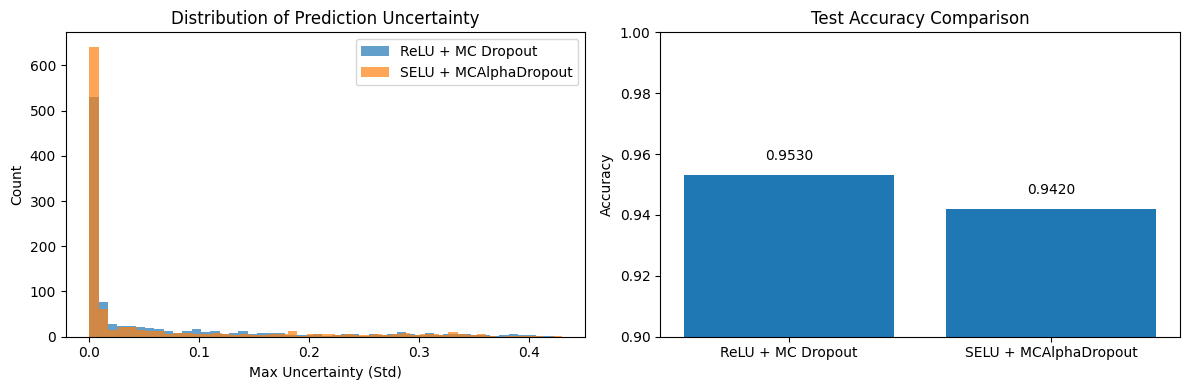

In [12]:
# Compare MC predictions from both models
print("\nComparing MC predictions from regular ReLU vs SELU models...")

# MC predictions from SELU model
mean_preds_selu, std_preds_selu, _ = mc_predict_tf(selu_model, X_test[:1000], n_samples=100)

# Compare uncertainty distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(std_preds.max(axis=1), bins=50, alpha=0.7, label='ReLU + MC Dropout')
axes[0].hist(std_preds_selu.max(axis=1), bins=50, alpha=0.7, label='SELU + MCAlphaDropout')
axes[0].set_xlabel('Max Uncertainty (Std)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Prediction Uncertainty')
axes[0].legend()

# Accuracy comparison
pred_relu = np.argmax(mean_preds, axis=1)
pred_selu = np.argmax(mean_preds_selu, axis=1)

acc_relu = np.mean(pred_relu == y_test[:1000])
acc_selu = np.mean(pred_selu == y_test[:1000])

axes[1].bar(['ReLU + MC Dropout', 'SELU + MCAlphaDropout'], [acc_relu, acc_selu])
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy Comparison')
axes[1].set_ylim(0.9, 1.0)

for i, acc in enumerate([acc_relu, acc_selu]):
    axes[1].text(i, acc + 0.005, f'{acc:.4f}', ha='center')

plt.tight_layout()
plt.show()

---
# Part B: Monte Carlo Dropout in PyTorch

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)

PyTorch version: 2.10.0+cu128
Using device: cuda


In [14]:
# Load MNIST for PyTorch
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Use subset
train_dataset = torch.utils.data.Subset(train_dataset, range(10000))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 406kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.02MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [15]:
class MCDropoutModel(nn.Module):
    """
    PyTorch model with MC Dropout capability.

    The key is to keep dropout in training mode during inference
    by using model.train() or the enable_dropout() method.
    """
    def __init__(self, dropout_rate=0.3):
        super(MCDropoutModel, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, 256)
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(256, 128)
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = F.relu(self.fc3(x))
        x = self.dropout3(x)
        x = self.fc4(x)
        return F.softmax(x, dim=1)

    def enable_dropout(self):
        """Enable dropout layers during inference."""
        for module in self.modules():
            if isinstance(module, nn.Dropout):
                module.train()

# Create model
mc_model_pt = MCDropoutModel(dropout_rate=0.3).to(device)
print(mc_model_pt)

MCDropoutModel(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)


In [16]:
# Training function
def train_pytorch_model(model, train_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0

        for data, target in train_loader:
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            total += target.size(0)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, "
                  f"Accuracy: {correct/total:.4f}")

    return model

# Train the model
print("Training MC Dropout Model (PyTorch)...")
mc_model_pt = train_pytorch_model(mc_model_pt, train_loader, epochs=20)

Training MC Dropout Model (PyTorch)...
Epoch 5/20, Loss: 1.5445, Accuracy: 0.9169
Epoch 10/20, Loss: 1.5335, Accuracy: 0.9271
Epoch 15/20, Loss: 1.5331, Accuracy: 0.9279
Epoch 20/20, Loss: 1.5222, Accuracy: 0.9389


In [17]:
def mc_predict_pytorch(model, data_loader, n_samples=100, device='cpu'):
    """
    Make MC predictions with PyTorch model.

    Args:
        model: PyTorch model with Dropout layers
        data_loader: DataLoader with test data
        n_samples: Number of MC forward passes
        device: Device to run on

    Returns:
        mean_preds, std_preds, all_preds, targets
    """
    model.eval()  # Set to eval mode first
    model.enable_dropout()  # But keep dropout active

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for _ in range(n_samples):
            sample_preds = []
            targets = []

            for data, target in data_loader:
                data = data.to(device)
                output = model(data)
                sample_preds.append(output.cpu().numpy())
                if len(all_predictions) == 0:
                    targets.append(target.numpy())

            all_predictions.append(np.concatenate(sample_preds, axis=0))
            if len(all_targets) == 0:
                all_targets = np.concatenate(targets, axis=0)

    all_predictions = np.array(all_predictions)
    mean_preds = all_predictions.mean(axis=0)
    std_preds = all_predictions.std(axis=0)

    return mean_preds, std_preds, all_predictions, all_targets

# Make MC predictions
print("Making MC predictions (100 samples)...")
mean_preds_pt, std_preds_pt, all_preds_pt, y_test_pt = mc_predict_pytorch(
    mc_model_pt, test_loader, n_samples=100, device=device
)

print(f"Mean predictions shape: {mean_preds_pt.shape}")
print(f"Std predictions shape: {std_preds_pt.shape}")

Making MC predictions (100 samples)...
Mean predictions shape: (10000, 10)
Std predictions shape: (10000, 10)


PyTorch - Examples with LOW uncertainty:


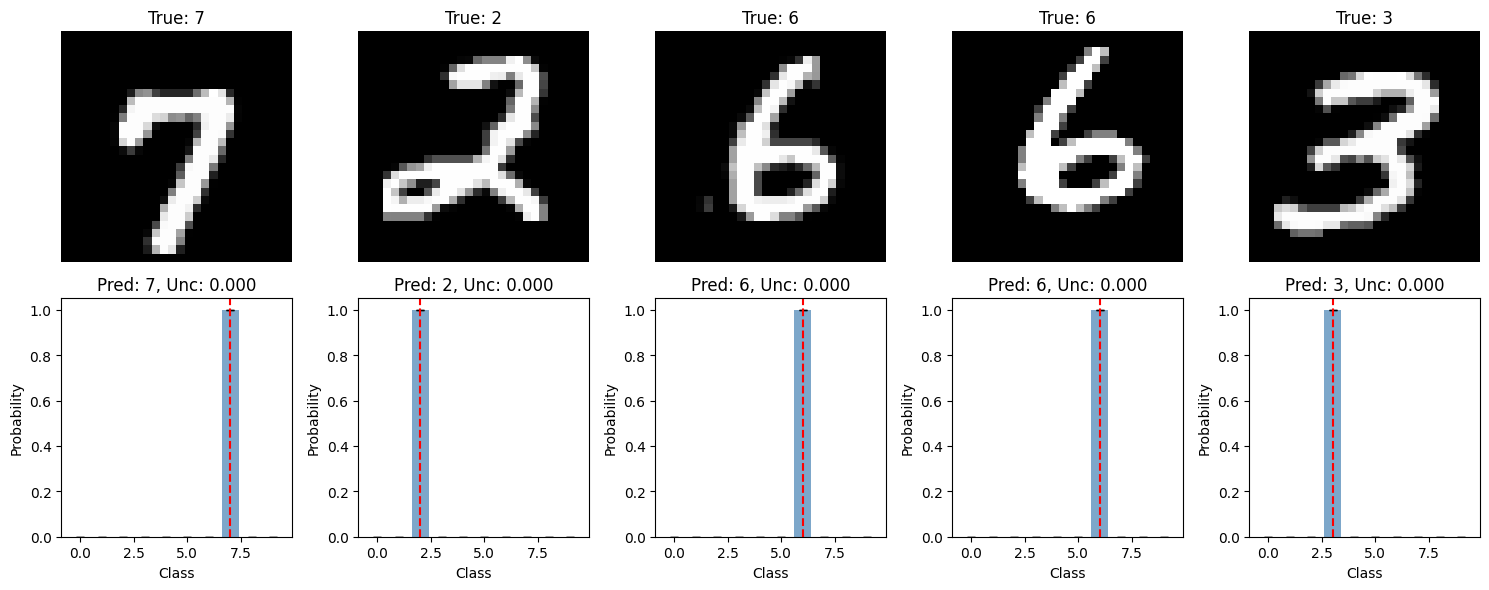


PyTorch - Examples with HIGH uncertainty:


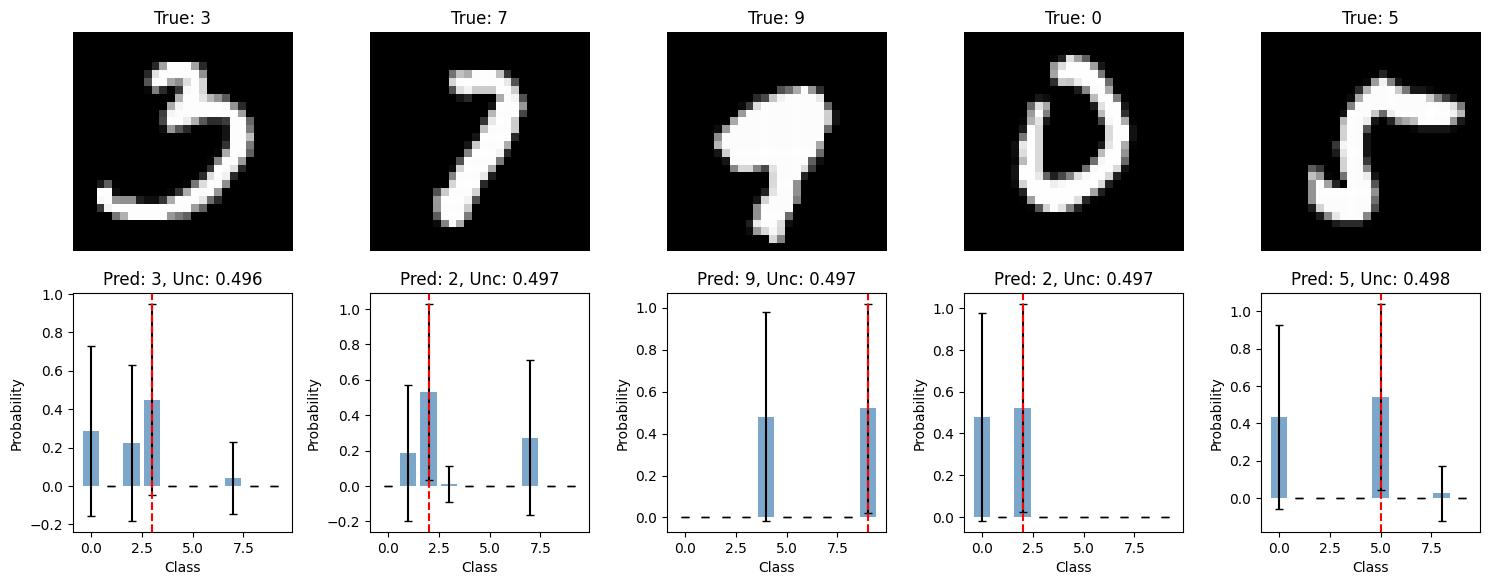

In [18]:
# Visualize PyTorch MC predictions
def visualize_pytorch_uncertainty(test_dataset, mean_preds, std_preds, indices):
    fig, axes = plt.subplots(2, len(indices), figsize=(15, 6))

    for i, idx in enumerate(indices):
        # Get image and label
        img, label = test_dataset[idx]

        # Show image
        axes[0, i].imshow(img.squeeze(), cmap='gray')
        axes[0, i].set_title(f"True: {label}")
        axes[0, i].axis('off')

        # Show prediction with uncertainty
        classes = np.arange(10)
        axes[1, i].bar(classes, mean_preds[idx], yerr=std_preds[idx],
                      capsize=3, alpha=0.7, color='steelblue')
        pred_class = np.argmax(mean_preds[idx])
        axes[1, i].axvline(x=pred_class, color='red', linestyle='--')
        axes[1, i].set_xlabel('Class')
        axes[1, i].set_ylabel('Probability')
        axes[1, i].set_title(f"Pred: {pred_class}, Unc: {std_preds[idx].max():.3f}")

    plt.tight_layout()
    plt.show()

# High confidence examples
low_unc_idx = np.argsort(std_preds_pt.max(axis=1))[:5]
print("PyTorch - Examples with LOW uncertainty:")
visualize_pytorch_uncertainty(test_dataset, mean_preds_pt, std_preds_pt, low_unc_idx)

# Low confidence examples
high_unc_idx = np.argsort(std_preds_pt.max(axis=1))[-5:]
print("\nPyTorch - Examples with HIGH uncertainty:")
visualize_pytorch_uncertainty(test_dataset, mean_preds_pt, std_preds_pt, high_unc_idx)

## Out-of-Distribution Detection

MC Dropout is useful for detecting out-of-distribution (OOD) samples. The model should show higher uncertainty on data it hasn't seen.

Testing on Out-of-Distribution data...


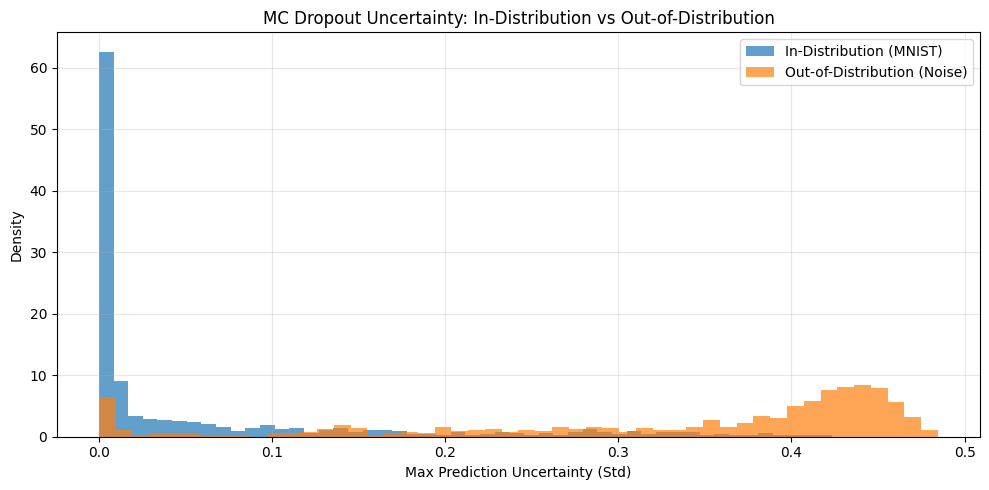


Average uncertainty on MNIST: 0.0606
Average uncertainty on Noise: 0.3337

Higher uncertainty on OOD data allows us to flag uncertain predictions!


In [19]:
# Create synthetic OOD data (rotated MNIST)
def create_ood_data(images, rotation_angle=90):
    """Rotate images to create OOD samples."""
    rotated = np.rot90(images.reshape(-1, 28, 28), k=rotation_angle//90, axes=(1, 2))
    return rotated.reshape(-1, 784)

# Create random noise as OOD
noise_data = np.random.randn(1000, 784).astype('float32')

# Get predictions on OOD data (TensorFlow model)
print("Testing on Out-of-Distribution data...")
mean_preds_ood, std_preds_ood, _ = mc_predict_tf(mc_model_tf, noise_data, n_samples=50)

# Compare uncertainty distributions
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(std_preds.max(axis=1), bins=50, alpha=0.7, label='In-Distribution (MNIST)', density=True)
ax.hist(std_preds_ood.max(axis=1), bins=50, alpha=0.7, label='Out-of-Distribution (Noise)', density=True)
ax.set_xlabel('Max Prediction Uncertainty (Std)')
ax.set_ylabel('Density')
ax.set_title('MC Dropout Uncertainty: In-Distribution vs Out-of-Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAverage uncertainty on MNIST: {std_preds.max(axis=1).mean():.4f}")
print(f"Average uncertainty on Noise: {std_preds_ood.max(axis=1).mean():.4f}")
print("\nHigher uncertainty on OOD data allows us to flag uncertain predictions!")

---
## Summary

### Monte Carlo Dropout Key Points:

| Aspect | Description |
|--------|-------------|
| **Concept** | Use dropout at inference time to estimate uncertainty |
| **Implementation** | Multiple forward passes with dropout enabled |
| **Uncertainty** | Standard deviation of predictions indicates confidence |
| **MCAlphaDropout** | Use with SELU activation to maintain self-normalization |

### Use Cases:
1. **Uncertainty quantification** - Know when the model is unsure
2. **Out-of-distribution detection** - Flag unusual inputs
3. **Active learning** - Select samples with high uncertainty for labeling
4. **Safety-critical applications** - Defer to humans when uncertain

### Best Practices:
- Use 50-100 MC samples for stable estimates
- Lower dropout rate (0.1-0.3) often works better for MC
- Combine with ensemble methods for even better uncertainty estimates